### Assignment 2: Small Models and Attention

In [14]:
import copy
import csv
import random
import re
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Question 1 : Softer Targets
Use this FashionMNIST MLP. Flatten each image before passing it to the model.

```python
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)
```

Use Adam, learning rate 0.001, batch size 128, and 10 epochs.

##### Part (a) : Train and Report
Train two models from identical initial weights, using these two training losses:

```python
hard_loss = nn.CrossEntropyLoss(label_smoothing=0.0)
soft_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
```

The soft target is 0.91 for the true class and 0.01 for each other class. Validation and test always use the hard loss.

For each model, report the selected epoch, test accuracy, and mean test confidence. Confidence is the largest softmax probability:

```python
confidence = torch.softmax(logits, dim=-1).max(dim=-1).values
```

In [15]:
# Loading FashionMNIST dataset

transform = transforms.ToTensor()
all_training = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=transform
)
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=transform
)
g = torch.Generator().manual_seed(42)
order = torch.randperm(60000, generator=g).tolist()
train_data = Subset(all_training, order[:6000])
val_data = Subset(all_training, order[6000:7000])

100.0%
100.0%
100.0%
100.0%


In [16]:
# Dataset Loaders
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=0, drop_last=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=0, drop_last=False)

# Building both models from identical weights
set_seed(42)
hard_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)
soft_model = copy.deepcopy(hard_model)

In [17]:
# Evaluation
eval_criterion = nn.CrossEntropyLoss(reduction="sum")

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_confidences = []
    
    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            loss = eval_criterion(logits, targets)
            total_loss += loss.item()
            
            probs = torch.softmax(logits, dim=-1)
            conf, preds = probs.max(dim=-1)
            
            total_correct += (preds == targets).sum().item()
            total_samples += targets.size(0)
            all_confidences.append(conf.cpu())
            
    mean_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    confidences = torch.cat(all_confidences)
    mean_confidence = confidences.mean().item()
    
    return mean_loss, accuracy, mean_confidence, confidences


In [18]:
def train_and_evaluate(model, train_loss_fn, model_name):
    print(f"\n{'='*20} {model_name} {'='*20}")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Fresh loader with seed 42 so both models see identical batch sequences
    train_loader = DataLoader(
        train_data,
        batch_size=128,
        shuffle=True,
        num_workers=0,
        drop_last=False,
        generator=torch.Generator().manual_seed(42),
    )
    
    best_val_loss = float("inf")
    best_epoch = -1
    best_weights = None
    
    for epoch in range(1, 11):
        model.train()
        train_loss_sum = 0.0
        train_samples = 0
        
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = train_loss_fn(logits, targets)
            loss.backward()
            optimizer.step()
            
            train_loss_sum += loss.item() * targets.size(0)
            train_samples += targets.size(0)
            
        train_loss = train_loss_sum / train_samples
        val_loss, val_acc, _, _ = evaluate(model, val_loader)
        print(f"Epoch {epoch:2d}/10 | Train Loss: {train_loss:.4f} | Val Loss (Hard): {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
        
        # Save checkpoint if lowest validation loss so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())
            
    print(f"\nSelected Best Epoch: Epoch {best_epoch} (Val Loss = {best_val_loss:.4f})")
    
    # Restore the best weights before test evaluation
    model.load_state_dict(best_weights)
    test_loss, test_acc, test_conf, test_confidences = evaluate(model, test_loader)
    
    return best_epoch, test_acc, test_conf, test_confidences

In [19]:
# Define the two losses
hard_loss = nn.CrossEntropyLoss(label_smoothing=0.0)
soft_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

# Train and evaluate both models
best_epoch_hard, test_acc_hard, test_conf_hard, confs_hard = train_and_evaluate(
    hard_model, hard_loss, "Model 1: Hard Targets (smoothing=0.0)"
)

best_epoch_soft, test_acc_soft, test_conf_soft, confs_soft = train_and_evaluate(
    soft_model, soft_loss, "Model 2: Soft Targets (smoothing=0.1)"
)

# Print Summary Table for Q1(a)
print("\n" + "="*70)
print(f"{'Model':<25} | {'Selected Epoch':<15} | {'Test Accuracy':<15} | {'Mean Confidence':<15}")
print("-" * 70)
print(f"{'Hard (smoothing=0.0)':<25} | Epoch {best_epoch_hard:<9} | {test_acc_hard*100:.2f}% ({test_acc_hard:.4f})  | {test_conf_hard:.4f}")
print(f"{'Soft (smoothing=0.1)':<25} | Epoch {best_epoch_soft:<9} | {test_acc_soft*100:.2f}% ({test_acc_soft:.4f})  | {test_conf_soft:.4f}")
print("="*70)



==================== Model 1: Hard Targets (smoothing=0.0) ====================
Epoch  1/10 | Train Loss: 1.1903 | Val Loss (Hard): 0.7546 | Val Acc: 73.00%
Epoch  2/10 | Train Loss: 0.7025 | Val Loss (Hard): 0.6328 | Val Acc: 78.20%
Epoch  3/10 | Train Loss: 0.5959 | Val Loss (Hard): 0.5530 | Val Acc: 80.20%
Epoch  4/10 | Train Loss: 0.5456 | Val Loss (Hard): 0.5328 | Val Acc: 81.70%
Epoch  5/10 | Train Loss: 0.5045 | Val Loss (Hard): 0.4974 | Val Acc: 83.60%
Epoch  6/10 | Train Loss: 0.4827 | Val Loss (Hard): 0.4999 | Val Acc: 82.10%
Epoch  7/10 | Train Loss: 0.4576 | Val Loss (Hard): 0.4798 | Val Acc: 83.70%
Epoch  8/10 | Train Loss: 0.4489 | Val Loss (Hard): 0.4593 | Val Acc: 85.00%
Epoch  9/10 | Train Loss: 0.4262 | Val Loss (Hard): 0.4639 | Val Acc: 82.90%
Epoch 10/10 | Train Loss: 0.4119 | Val Loss (Hard): 0.4775 | Val Acc: 83.30%

Selected Best Epoch: Epoch 8 (Val Loss = 0.4593)

==================== Model 2: Soft Targets (smoothing=0.1) ====================
Epoch  1/10 | Trai

##### Part (b) : Compare Confidence
Plot both test-confidence histograms on one axis. Use the same 20 equal-width bins from 0 to 1 and label the two models.


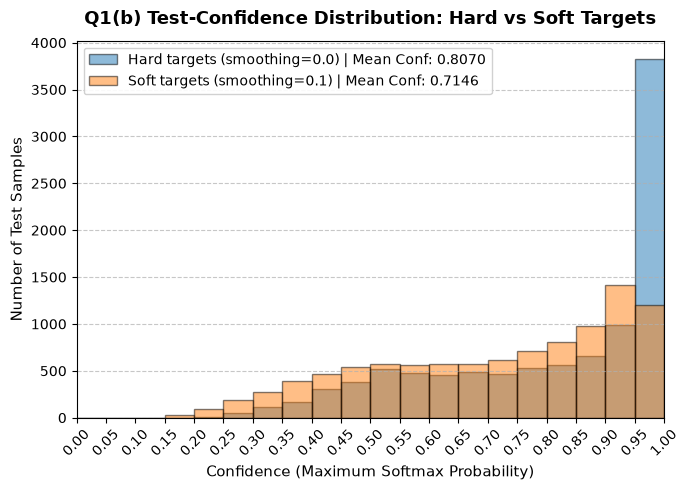

In [23]:
plt.figure(figsize=(7, 5))
bins = np.linspace(0.0, 1.0, 21)

plt.hist(
    confs_hard.numpy(),
    bins=bins,
    alpha=0.5,
    color="#1f77b4",
    edgecolor="black",
    label=f"Hard targets (smoothing=0.0) | Mean Conf: {test_conf_hard:.4f}",
)
plt.hist(
    confs_soft.numpy(),
    bins=bins,
    alpha=0.5,
    color="#ff7f0e",
    edgecolor="black",
    label=f"Soft targets (smoothing=0.1) | Mean Conf: {test_conf_soft:.4f}",
)
plt.title("Q1(b) Test-Confidence Distribution: Hard vs Soft Targets", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Confidence (Maximum Softmax Probability)", fontsize=11)
plt.ylabel("Number of Test Samples", fontsize=11)
plt.xticks(bins, rotation=45)
plt.xlim(0.0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(fontsize=10, loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()

##### Part (c) : Explain
In three or four sentences, describe the changes in accuracy and confidence. Why do softer targets reduce the pressure toward extreme confidence? Refer to your results, even if accuracy did not improve.


In our FashionMNIST experiment, introducing label smoothing preserved test accuracy with a slight increase from **82.26% to 82.54%**, while significantly reducing the mean test confidence from **0.8070 to 0.7146**. With hard one-hot targets, cross-entropy loss reaches zero only when the winning logit diverges to positive infinity relative to all other logits ($z_{\text{true}} - z_j \to +\infty$), creating persistent gradient pressure that inflates weight magnitudes and drives predictions into the extreme $[0.95, 1.0]$ confidence bin. In contrast, softer targets ($0.91$ for the correct class and $0.01$ for incorrect classes) achieve their theoretical loss minimum at a finite logit difference of $z_{\text{true}}^* - z_j^* = \ln(0.91 / 0.01) \approx 4.51$. Consequently, once this finite separation is attained, gradients diminish, eliminating the incentive for overconfidence and shifting the test confidence distribution into a well-calibrated range.


#### Question 2 : Predict the next letter

In [24]:
with open("names.csv", encoding="utf-8-sig", newline="") as f:
    names = sorted({
        re.sub(r"[^a-z]", "", row["Name"].lower())
        for row in csv.DictReader(f)
    } - {""})
assert len(names) == 6478

g = torch.Generator().manual_seed(42)
order = torch.randperm(len(names), generator=g).tolist()
train_names = [names[i] for i in order[:5182]]
val_names = [names[i] for i in order[5182:5829]]
test_names = [names[i] for i in order[5829:]]
stoi = {ch: i for i, ch in enumerate("-abcdefghijklmnopqrstuvwxyz")}

##### Part (a) : Train and Evaluate